# Periodic-cardinal character Sobolev student

Successor to [`sobolev_student_character_ramped.ipynb`](sobolev_student_character_ramped.ipynb).  The ramped notebook removed the two-phase boundary kink but did not address the residual blocker: the polynomial Hermite-Lagrange teacher does not satisfy modular-addition periodicity off the lattice.  Concretely, ``T_{ij} = \zeta^{(i+j)\bmod p}`` is exact at lattice nodes, but the polynomial einsum in [`sobolev_distill_character/teacher.py`](../../sobolev_distill_character/teacher.py) interpolates ``(\mathrm{Re}, \mathrm{Im})`` linearly between nodes, so off-lattice ``|f_H| \ne 1`` and the smooth wrap from $(p-1, 0) \to (0, 0)$ does not happen.

This notebook swaps in the **periodic-cardinal (Dirichlet-kernel) teacher** ``build_character_teacher_mesh_periodic`` -- the trig-polynomial cardinal basis on $K = p$ equispaced nodes.  Because $\zeta^{(x+y)/p}$ is a single-Fourier-mode signal in the basis' band, the periodic interpolant matches the analytic value AND its gradient *exactly* on the entire mesh; ``|f_H| = 1`` everywhere, and the off-lattice wrap is the smooth torus interpolant the previous notebooks were missing.  See [`graphic_zero/surfaces_barycentric.py`](../../graphic_zero/surfaces_barycentric.py) ``periodic_cardinal{,_prime,_second}`` for the closed-form DFT helpers.

The student stack, the ramped schedule, and the einsum kernels are unchanged: only the teacher fields differ.  Sections: §1 config, §2 build both teachers, §3 train ramped student vs polynomial teacher, §4 train ramped student vs periodic teacher, §5 diagnostics side-by-side, §6 heatmaps, §7 modular tables, §8 probe bundle + verdict, §9 architecture sweep under periodic teacher, §10 factorisation-pressure sweep under periodic teacher, §11 delta table (poly vs periodic), §12 takeaways.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import math
import sys
import time
from dataclasses import replace
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np


def _polys_root_for_import() -> Path:
    here = Path.cwd().resolve()
    candidates = [
        here / 'graphic_zero_character',
        here.parent / 'graphic_zero_character',
        here.parent.parent / 'graphic_zero_character',
        here.parent.parent.parent / 'graphic_zero_character',
        here / 'ml' / 'polys' / 'graphic_zero_character',
        here.parent / 'ml' / 'polys' / 'graphic_zero_character',
    ]
    for g in candidates:
        if g.is_dir() and (g / '__init__.py').exists():
            return g.parent
    raise FileNotFoundError('Could not locate ml/polys.')


_polys = _polys_root_for_import()
if str(_polys) not in sys.path:
    sys.path.insert(0, str(_polys))

from sobolev_distill_character import (
    CharacterStudentConfig,
    CharacterTrainConfig,
    LinearRampSchedule,
    LossWeights,
    build_character_dataset,
    build_character_teacher_mesh,
    build_character_teacher_mesh_periodic,
    evaluate_diagnostics_character,
    f_arith_character_batched,
    make_character_student,
    run_all_probes_character,
    train_student_character_scheduled,
)
from sobolev_distill_character.model import CoordMeta

print('jax devices:', jax.devices())

jax devices: [CudaDevice(id=0)]


E0515 09:19:36.895501   27453 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0515 09:19:36.911053   27297 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [2]:
MODULUS = 8
MAX_N = 8
MESH_N = 64
LAM = 1.0
EPOCHS_TOTAL = 2000
RAMP_EPOCHS = 200
GRAD_RAMP_END = 0.05
BATCH_SIZE = 256

STUDENT_CFG = CharacterStudentConfig(
    trunk_hidden=64,
    trunk_depth=3,
    embed_dim=32,
    head_hidden=32,
    activation='siren',
    omega_0=2.5,
    axis_probe=True,
)

WEIGHTS_BASE = LossWeights(
    value=1.0,
    grad=0.0,
    hess=0.0,
    hess_reg=1e-4,
    unit_circle=0.5,
    axis=1.0,
    energy_value=0.5,
    energy_pd=0.0,
    pd_pos_weight=1.0,
)

SCHEDULE = LinearRampSchedule(
    base=WEIGHTS_BASE,
    field='grad',
    start=0.0,
    end=GRAD_RAMP_END,
    ramp_epochs=RAMP_EPOCHS,
)

TRAIN_CFG = CharacterTrainConfig(
    epochs=EPOCHS_TOTAL,
    batch_size=BATCH_SIZE,
    lr_init=1e-3,
    lr_min=1e-5,
    grad_clip=1.0,
    lattice_frac=0.4,
    chebyshev_frac=0.4,
    weights=WEIGHTS_BASE,
    log_every=50,
    seed=0,
)

print('student cfg + ramp inherited from sobolev_student_character_ramped.ipynb')
print(f'schedule: grad ramps {SCHEDULE.start} → {SCHEDULE.end} over {SCHEDULE.ramp_epochs} epochs')

student cfg + ramp inherited from sobolev_student_character_ramped.ipynb
schedule: grad ramps 0.0 → 0.05 over 200 epochs


## 2. Build both teachers (polynomial vs periodic)

Same mesh, same modulus, same lattice; only the per-axis cardinal envelopes differ.  Print the side-by-side max ``||V|^2 - 1|`` over the dense mesh as a structural sanity check: the polynomial teacher fails unit-modulus off-lattice, the periodic teacher does not.

In [3]:
nodes = np.arange(MAX_N, dtype=np.float64)

teacher_poly = build_character_teacher_mesh(
    nodes_x=nodes,
    nodes_y=nodes,
    p=MODULUS,
    mesh_n=MESH_N,
    lam=LAM,
)
ds_poly = build_character_dataset(teacher_poly)

teacher_per = build_character_teacher_mesh_periodic(
    nodes_x=nodes,
    nodes_y=nodes,
    p=MODULUS,
    mesh_n=MESH_N,
    lam=LAM,
)
ds_per = build_character_dataset(teacher_per)

for tag, t in [('poly', teacher_poly), ('per ', teacher_per)]:
    V = np.asarray(t.V_re) + 1j * np.asarray(t.V_im)
    abs_dev = float(np.max(np.abs(np.abs(V) - 1.0)))
    nme_min = float(np.asarray(t.node_min_eig).min())
    print(f'teacher_{tag}: mesh shape Nx={t.xs.shape[0]}, Ny={t.ys.shape[0]}; '
          f'max ||V|-1| = {abs_dev:8.4e}; min node_min_eig = {nme_min:8.4f}')

print(f'\nteacher_poly mesh ||V|-1| (max) is the structural failure mode the periodic teacher fixes.')

teacher_poly: mesh shape Nx=64, Ny=64; max ||V|-1| = 1.2224e+02; min node_min_eig =   5.6033
teacher_per : mesh shape Nx=64, Ny=64; max ||V|-1| = 1.1921e-07; min node_min_eig =   0.3084

teacher_poly mesh ||V|-1| (max) is the structural failure mode the periodic teacher fixes.


## 3. Helper: train the ramped student against a chosen teacher

Identical ramp / student / hyperparameters; only `ds` (dataset built from the chosen teacher) changes.  Returns ``(student, history, diag, bundle, train_seconds)``.

In [4]:
def train_ramped_against(teacher_, ds_, *, seed: int = 0):
    student = make_character_student(jax.random.PRNGKey(seed), STUDENT_CFG)
    cfg = replace(TRAIN_CFG, weights=SCHEDULE.base, seed=seed)
    t0 = time.time()
    student, history = train_student_character_scheduled(student, ds_, cfg, SCHEDULE)
    train_s = time.time() - t0
    diag = evaluate_diagnostics_character(student, ds_, teacher_)
    bundle = run_all_probes_character(student, ds_, teacher_, diagnostics=diag)
    return {
        'student': student,
        'history': history,
        'diag': diag,
        'bundle': bundle,
        'train_s': train_s,
    }

## 3a. Train ramped student against the polynomial teacher (`poly_ramp`)

In [5]:
poly_run = train_ramped_against(teacher_poly, ds_poly, seed=0)
print(f'poly_ramp trained in {poly_run["train_s"]:.1f}s')
print(f'first: {poly_run["history"][0]}')
print(f'last:  {poly_run["history"][-1]}')

poly_ramp trained in 124.4s
first: {'epoch': 0, 'loss': 29.680950164794922, 'energy_loss': 26.413745880126953, 'energy_pd_bce': 0.6939296126365662, 'energy_pd_n_pos': 126.0, 'energy_value_mse': 52.827491760253906, 'sobolev_axis_mse': 2.0241193771362305, 'sobolev_grad_mse': 191.80014038085938, 'sobolev_hess_mse': 1037005440.0, 'sobolev_hess_reg': 0.2413914054632187, 'sobolev_loss': 3.2672035694122314, 'sobolev_unit_circle_pen': 1.319602608680725, 'sobolev_value_mse': 0.5832588076591492, 'total_loss': 29.680950164794922}
last:  {'epoch': 1999, 'loss': 14.938102722167969, 'energy_loss': 1.339930534362793, 'energy_pd_bce': 1.0514159202575684, 'energy_pd_n_pos': 123.0, 'energy_value_mse': 2.679861068725586, 'sobolev_axis_mse': 0.05470702797174454, 'sobolev_grad_mse': 256.7521667480469, 'sobolev_hess_mse': 848251648.0, 'sobolev_hess_reg': 5313.0283203125, 'sobolev_loss': 13.598172187805176, 'sobolev_unit_circle_pen': 0.19378958642482758, 'sobolev_value_mse': 0.07765939086675644, 'total_loss'

## 3b. Train ramped student against the periodic teacher (`per_ramp`)

per_ramp trained in 109.9s
first: {'epoch': 0, 'loss': 3.34916353225708, 'energy_loss': 0.5641087293624878, 'energy_pd_bce': 0.6960172057151794, 'energy_pd_n_pos': 123.0, 'energy_value_mse': 1.1282174587249756, 'sobolev_axis_mse': 1.982470989227295, 'sobolev_grad_mse': 13.482605934143066, 'sobolev_hess_mse': 205.89132690429688, 'sobolev_hess_reg': 0.22052046656608582, 'sobolev_loss': 2.7850546836853027, 'sobolev_unit_circle_pen': 0.699928879737854, 'sobolev_value_mse': 0.45259732007980347, 'total_loss': 3.34916353225708}
last:  {'epoch': 1999, 'loss': 0.24899011850357056, 'energy_loss': 0.22854332625865936, 'energy_pd_bce': 0.7104008197784424, 'energy_pd_n_pos': 126.0, 'energy_value_mse': 0.4570866525173187, 'sobolev_axis_mse': 0.00111397635191679, 'sobolev_grad_mse': 0.01714090071618557, 'sobolev_hess_mse': 8.352493286132812, 'sobolev_hess_reg': 182.96524047851562, 'sobolev_loss': 0.02044679969549179, 'sobolev_unit_circle_pen': 0.00022285217710305005, 'sobolev_value_mse': 6.7831293563

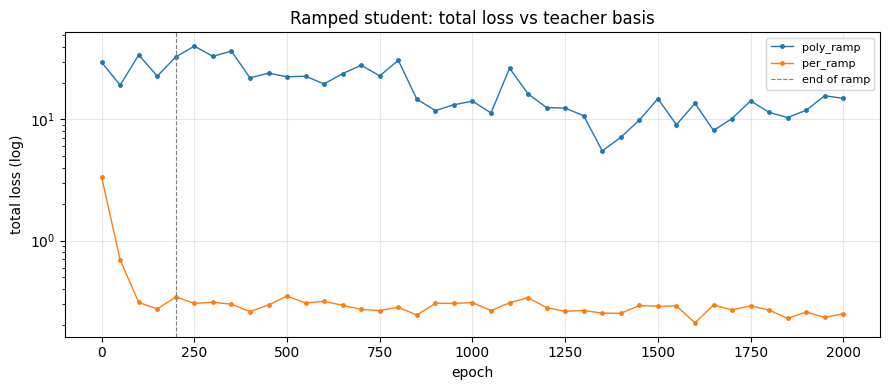

In [6]:
per_run = train_ramped_against(teacher_per, ds_per, seed=0)
print(f'per_ramp trained in {per_run["train_s"]:.1f}s')
print(f'first: {per_run["history"][0]}')
print(f'last:  {per_run["history"][-1]}')

fig, ax = plt.subplots(figsize=(9, 4))
for tag, run in [('poly_ramp', poly_run), ('per_ramp', per_run)]:
    ep = [h['epoch'] for h in run['history']]
    losses = [h['loss'] for h in run['history']]
    ax.plot(ep, losses, marker='o', markersize=2.5, linewidth=1.0, label=tag)
ax.axvline(RAMP_EPOCHS, color='gray', linestyle='--', linewidth=0.8, label='end of ramp')
ax.set_xlabel('epoch')
ax.set_ylabel('total loss (log)')
ax.set_yscale('log')
ax.set_title('Ramped student: total loss vs teacher basis')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Diagnostics side-by-side

In [7]:
header = f"  {'metric':32s}  {'poly_ramp':>14s}  {'per_ramp':>14s}"
print(header)
print('-' * len(header))
for k in poly_run['diag'].as_dict():
    vp = poly_run['diag'].as_dict()[k]
    vq = per_run['diag'].as_dict()[k]
    if isinstance(vp, float) and isinstance(vq, float):
        print(f'  {k:32s}  {vp:14.6g}  {vq:14.6g}')
    else:
        print(f'  {k:32s}  {str(vp):>14s}  {str(vq):>14s}')

  metric                                 poly_ramp        per_ramp
------------------------------------------------------------------
  node_value_mse                         0.0389571     0.000178152
  node_grad_mse                            6.39017       0.0162231
  offlattice_value_mse                    0.333266     0.000140554
  energy_value_mse                          3.9836        0.934517
  energy_pd_auroc                         0.466629         0.40768
  modular_recovery_accuracy               0.953125               1
  modular_recovery_accuracy_train         0.980392               1
  modular_recovery_accuracy_holdout        0.846154               1
  modular_acc_train_minus_holdout         0.134238               0
  unit_circle_residual                   0.0649011      0.00701416


## 6. Predicted vs teacher heatmaps (both teachers)

Each row is a teacher / student pair.  The diff column should look qualitatively cleaner for the periodic teacher: no off-lattice unit-modulus violation forcing the student to fit a non-circular target.

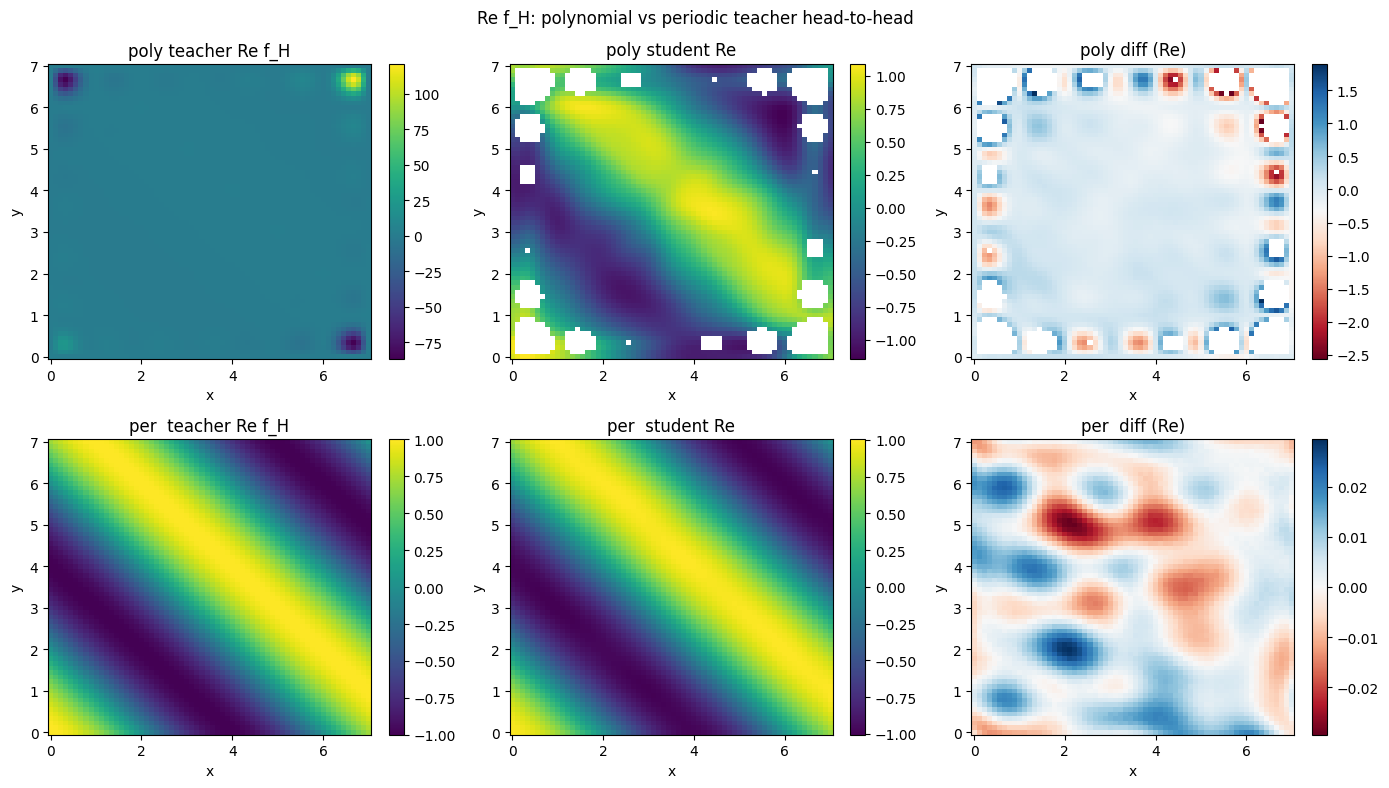

In [8]:
def _heatmap_panel(axes_row, label_prefix, teacher_, student_, ds_):
    pred_norm = np.asarray(f_arith_character_batched(student_, ds_.xy))
    pred_re = pred_norm[:, 0] * ds_.norm.v_re_std + ds_.norm.v_re_mean
    pred_im = pred_norm[:, 1] * ds_.norm.v_im_std + ds_.norm.v_im_mean
    xy_raw = np.asarray(ds_.xy_raw)
    Nx = teacher_.xs.shape[0]
    Ny = teacher_.ys.shape[0]
    pred_re_grid = np.full((Nx, Ny), np.nan)
    pred_im_grid = np.full((Nx, Ny), np.nan)
    x_axis = np.asarray(teacher_.xs)
    y_axis = np.asarray(teacher_.ys)
    for k in range(xy_raw.shape[0]):
        xi = int(np.argmin(np.abs(x_axis - xy_raw[k, 0])))
        yj = int(np.argmin(np.abs(y_axis - xy_raw[k, 1])))
        pred_re_grid[xi, yj] = pred_re[k]
        pred_im_grid[xi, yj] = pred_im[k]
    target_re = np.asarray(teacher_.V_re)
    pred_grid = pred_re_grid
    diff = pred_grid.T - target_re.T
    im0 = axes_row[0].pcolormesh(x_axis, y_axis, target_re.T, shading='auto')
    axes_row[0].set_title(f'{label_prefix} teacher Re f_H')
    im1 = axes_row[1].pcolormesh(x_axis, y_axis, pred_grid.T, shading='auto')
    axes_row[1].set_title(f'{label_prefix} student Re')
    im2 = axes_row[2].pcolormesh(x_axis, y_axis, diff, shading='auto', cmap='RdBu')
    axes_row[2].set_title(f'{label_prefix} diff (Re)')
    for im, ax in [(im0, axes_row[0]), (im1, axes_row[1]), (im2, axes_row[2])]:
        plt.colorbar(im, ax=ax, fraction=0.046)
        ax.set_xlabel('x')
        ax.set_ylabel('y')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
_heatmap_panel(axes[0], 'poly', teacher_poly, poly_run['student'], ds_poly)
_heatmap_panel(axes[1], 'per ', teacher_per, per_run['student'], ds_per)
fig.suptitle('Re f_H: polynomial vs periodic teacher head-to-head')
fig.tight_layout()
plt.show()

## 7. Recovered modular addition tables (both teachers)

modular top-1 accuracy:  poly = 0.9531  |  periodic = 1.0000


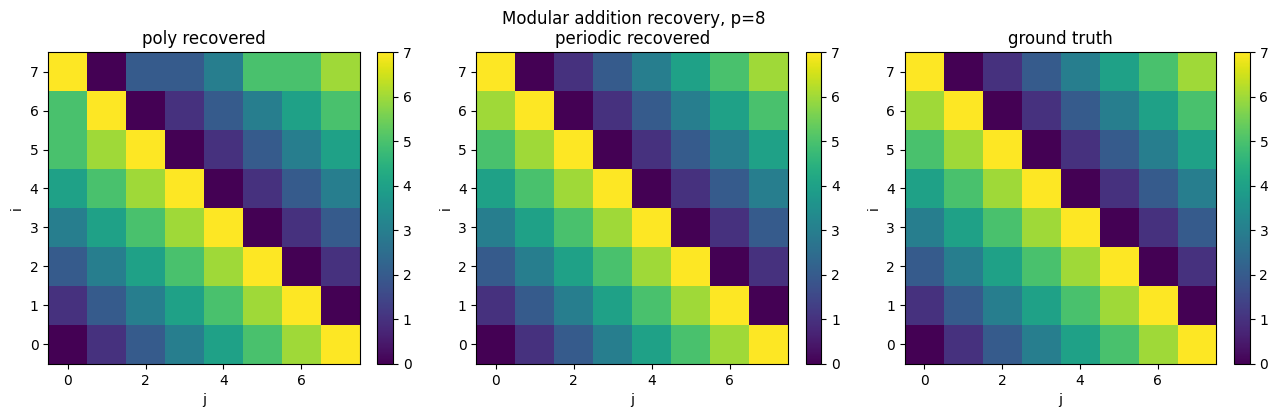

In [9]:
def _modular_table(student_, ds_, p):
    is_node = np.asarray(ds_.is_node)
    xy_lat_raw = np.asarray(ds_.xy_raw)[is_node]
    pred_norm_lat = np.asarray(f_arith_character_batched(student_, ds_.xy[is_node]))
    z = (
        pred_norm_lat[:, 0] * ds_.norm.v_re_std + ds_.norm.v_re_mean
    ) + 1j * (pred_norm_lat[:, 1] * ds_.norm.v_im_std + ds_.norm.v_im_mean)
    nodes_p = np.arange(p, dtype=np.float64)
    i_idx = np.argmin(np.abs(xy_lat_raw[:, 0:1] - nodes_p[None, :]), axis=1)
    j_idx = np.argmin(np.abs(xy_lat_raw[:, 1:2] - nodes_p[None, :]), axis=1)
    truth = (i_idx + j_idx) % p
    recovered = (np.round(p * np.angle(z) / (2.0 * math.pi)).astype(int)) % p
    rec_table = -np.ones((p, p), dtype=int)
    for ii, jj, r in zip(i_idx, j_idx, recovered):
        rec_table[int(ii), int(jj)] = int(r)
    return float((recovered == truth).mean()), rec_table

p = MODULUS
ground_truth_table = (np.arange(p)[:, None] + np.arange(p)[None, :]) % p
acc_poly, rec_poly = _modular_table(poly_run['student'], ds_poly, p)
acc_per, rec_per = _modular_table(per_run['student'], ds_per, p)
print(f'modular top-1 accuracy:  poly = {acc_poly:.4f}  |  periodic = {acc_per:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, mat, title in zip(
    axes,
    [rec_poly, rec_per, ground_truth_table],
    ['poly recovered', 'periodic recovered', 'ground truth'],
):
    im = ax.imshow(mat, origin='lower', cmap='viridis')
    ax.set_xlabel('j'); ax.set_ylabel('i'); ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f'Modular addition recovery, p={p}')
fig.tight_layout()
plt.show()

## 8. Probe bundle and verdict (both teachers)

``pd_certificate`` is structurally degenerate at $p = 8$ regardless of teacher (the BCE has no negatives), so we report ``three_of_three`` after dropping it.

In [10]:
def _print_verdict(label, bundle):
    v_full = bundle.verdict()
    v_skip = {k: ok for k, ok in v_full.items() if k not in {'pd_certificate', 'all_four'}}
    v_skip['three_of_three'] = bool(all(v_skip.values()))
    print(f'--- {label} verdict (pd_certificate dropped at p=8) ---')
    for k, ok in v_skip.items():
        print(f'  {k:32s} : {ok}')
    print()

_print_verdict('poly_ramp', poly_run['bundle'])
_print_verdict('per_ramp ', per_run['bundle'])

--- poly_ramp verdict (pd_certificate dropped at p=8) ---
  unit_circle_following            : True
  arithmetic_axes_linear           : False
  modular_recovery_ok              : True
  modular_generalisation_ok        : False
  all_five                         : False
  three_of_three                   : False

--- per_ramp  verdict (pd_certificate dropped at p=8) ---
  unit_circle_following            : True
  arithmetic_axes_linear           : True
  modular_recovery_ok              : True
  modular_generalisation_ok        : True
  all_five                         : False
  three_of_three                   : False



/tmp/ipykernel_27297/3796472099.py:2: UserWarning: Memorisation / uneven fit suspected: modular train_acc=0.9804, holdout_acc=0.8462, train_minus_holdout=0.1342 (threshold 0.1).
  v_full = bundle.verdict()


## 9. Architecture sweep under the periodic teacher (was §9 in the ramped notebook)

Same five single-knob variants as the ramped notebook, all under the same ramp `grad: 0 → 0.05` over `RAMP_EPOCHS = 200`, but with the *periodic* teacher.

In [11]:
def train_and_score_periodic(
    teacher_,
    ds_,
    student_cfg,
    schedule,
    *,
    train_overrides=None,
    epochs=EPOCHS_TOTAL,
    seed=0,
    tag='',
):
    coord_meta = (
        CoordMeta.from_dataset(ds_) if student_cfg.trunk_kind == 'fourier' else None
    )
    student_ = make_character_student(
        jax.random.PRNGKey(seed), student_cfg, coord_meta=coord_meta
    )
    cfg = replace(
        TRAIN_CFG,
        epochs=epochs,
        weights=schedule.base,
        seed=seed,
        **(train_overrides or {}),
    )
    t0 = time.time()
    student_, hist = train_student_character_scheduled(student_, ds_, cfg, schedule)
    train_s = time.time() - t0
    diag_ = evaluate_diagnostics_character(student_, ds_, teacher_)
    bundle_ = run_all_probes_character(student_, ds_, teacher_, diagnostics=diag_)
    return {
        'tag': tag,
        'student': student_,
        'diag': diag_,
        'bundle': bundle_,
        'train_s': train_s,
        'history': hist,
    }

BASE_NO_AXIS = replace(WEIGHTS_BASE, axis=0.0)
SCHED_NO_AXIS = replace(SCHEDULE, base=BASE_NO_AXIS)
STUDENT_OMEGA6 = replace(STUDENT_CFG, omega_0=6.0)
STUDENT_GELU = replace(STUDENT_CFG, activation='gelu', axis_probe=False)
BASE_HESS = replace(WEIGHTS_BASE, hess=0.0)
SCHED_HESS = LinearRampSchedule(BASE_HESS, 'hess', 0.0, 1e-7, RAMP_EPOCHS)

ARCH_SWEEP_PER = [
    ('baseline_per',    STUDENT_CFG,    SCHEDULE,        None),
    ('omega6_per',      STUDENT_OMEGA6, SCHEDULE,        None),
    ('gelu_per',        STUDENT_GELU,   SCHED_NO_AXIS,   None),
    ('hess_on_per',     STUDENT_CFG,    SCHED_HESS,      None),
    ('cheby_heavy_per', STUDENT_CFG,    SCHEDULE,        {'lattice_frac': 0.2, 'chebyshev_frac': 0.6}),
]

arch_results_per = {}
header = (
    f"{'tag':18s} | {'mod':>5s} | {'unit':>6s} | {'node_v':>8s} | {'offl_v':>8s} | "
    f"{'node_g':>7s} | {'R2_T_re':>7s} | {'R2_T_im':>7s} | {'pass/3':>6s} | {'t(s)':>6s}"
)
print(header)
print('-' * len(header))
for tag, scfg, sched, overrides in ARCH_SWEEP_PER:
    out = train_and_score_periodic(teacher_per, ds_per, scfg, sched, train_overrides=overrides, tag=tag)
    arch_results_per[tag] = out
    d = out['diag']; b = out['bundle']
    v = b.verdict(min_pd_auroc=0.0)
    n_pass = sum(int(o) for k, o in v.items() if k not in ('all_four', 'pd_certificate'))
    r2_T_re = b.probes.r2.get('Re T[i,j]', float('nan'))
    r2_T_im = b.probes.r2.get('Im T[i,j]', float('nan'))
    print(
        f"{tag:18s} | {d.modular_recovery_accuracy:5.3f} | {d.unit_circle_residual:6.4f} | "
        f"{d.node_value_mse:8.4g} | {d.offlattice_value_mse:8.4g} | {d.node_grad_mse:7.3g} | "
        f"{r2_T_re:+7.3f} | {r2_T_im:+7.3f} | {n_pass:>6d} | {out['train_s']:6.1f}"
    )

tag                |   mod |   unit |   node_v |   offl_v |  node_g | R2_T_re | R2_T_im | pass/3 |   t(s)
---------------------------------------------------------------------------------------------------------


baseline_per       | 1.000 | 0.0070 | 0.0001782 | 0.0001406 |  0.0162 |  +0.991 |  +0.994 |      5 |  108.4


omega6_per         | 1.000 | 0.0102 | 0.0001565 | 6.268e-05 | 0.00549 |  +0.972 |  +0.977 |      5 |  109.6


gelu_per           | 1.000 | 0.0055 | 0.0001382 | 8.906e-05 | 0.00976 |  +0.976 |  +0.999 |      5 |  108.8


hess_on_per        | 1.000 | 0.0112 | 0.001892 | 0.0009903 |   0.457 |  +0.978 |  +0.996 |      5 |  113.0


cheby_heavy_per    | 1.000 | 0.0073 | 0.0001631 | 0.0001395 |  0.0221 |  +0.985 |  +0.982 |      5 |  111.3


## 10. Factorisation-pressure sweep under the periodic teacher (was §10 in the ramped notebook)

- **(A) Auxiliary axis loss** -- baseline SIREN trunk + `AxisProbeHead`, `axis = 1.0`.
- **(B) Fixed Fourier-feature trunk** -- `trunk_kind='fourier'`, axis probes are linearly trivial by construction.
- **(C) Factored trunk + small MLP head** -- `trunk_kind='factored'` with `axis_emb=16`.

A baseline SIREN with no axis loss is included as a regression check.

In [12]:
SIREN_NO_AXIS = replace(STUDENT_CFG, axis_probe=False)
A_CFG = STUDENT_CFG
B_CFG = replace(
    STUDENT_CFG,
    trunk_kind='fourier',
    fourier_K=4,
    activation='gelu',
    axis_probe=False,
)
C_CFG = replace(
    STUDENT_CFG,
    trunk_kind='factored',
    axis_emb=16,
    activation='gelu',
    axis_probe=False,
)

FACTOR_VARIANTS_PER = [
    ('baseline_siren_per', SIREN_NO_AXIS, SCHED_NO_AXIS),
    ('A_axis_loss_per',    A_CFG,         SCHEDULE),
    ('B_fourier_per',      B_CFG,         SCHED_NO_AXIS),
    ('C_factored_per',     C_CFG,         SCHED_NO_AXIS),
]

factor_results_per = {}
header = (
    f"{'tag':22s} | {'mod':>5s} | {'unit':>6s} | {'node_v':>8s} | {'offl_v':>8s} | "
    f"{'R2_zi_re':>8s} | {'R2_zj_re':>8s} | {'R2_T_re':>7s} | {'pass/3':>6s} | {'t(s)':>6s}"
)
print(header)
print('-' * len(header))
for tag, scfg, sched in FACTOR_VARIANTS_PER:
    out = train_and_score_periodic(teacher_per, ds_per, scfg, sched, tag=tag)
    factor_results_per[tag] = out
    d = out['diag']; b = out['bundle']
    v = b.verdict(min_pd_auroc=0.0)
    n_pass = sum(int(o) for k, o in v.items() if k not in ('all_four', 'pd_certificate'))
    r2 = b.probes.r2
    print(
        f"{tag:22s} | {d.modular_recovery_accuracy:5.3f} | {d.unit_circle_residual:6.4f} | "
        f"{d.node_value_mse:8.4g} | {d.offlattice_value_mse:8.4g} | "
        f"{r2.get('Re zeta^i', float('nan')):+8.3f} | {r2.get('Re zeta^j', float('nan')):+8.3f} | "
        f"{r2.get('Re T[i,j]', float('nan')):+7.3f} | {n_pass:>6d} | {out['train_s']:6.1f}"
    )

print('\n--- per-variant verdict (periodic teacher, pd_certificate dropped) ---')
for tag, out in factor_results_per.items():
    v = out['bundle'].verdict(min_pd_auroc=0.0)
    keys = ('unit_circle_following', 'arithmetic_axes_linear', 'modular_recovery_ok')
    flags = ', '.join(f'{k}={v[k]}' for k in keys)
    print(f'  {tag:22s} : {flags}')

tag                    |   mod |   unit |   node_v |   offl_v | R2_zi_re | R2_zj_re | R2_T_re | pass/3 |   t(s)
---------------------------------------------------------------------------------------------------------------


baseline_siren_per     | 1.000 | 0.0085 | 0.0002194 | 0.0001611 |   -0.655 |   +0.560 |  +0.636 |      5 |  109.4


A_axis_loss_per        | 1.000 | 0.0070 | 0.0001782 | 0.0001406 |   +0.997 |   +0.993 |  +0.991 |      5 |  112.1


B_fourier_per          | 1.000 | 0.0110 | 0.0001672 | 7.807e-05 |   +1.000 |   +1.000 |  -0.913 |      3 |  106.3


C_factored_per         | 1.000 | 0.0105 | 0.0004154 | 0.0003239 |   +1.000 |   +1.000 |  -0.871 |      3 |  125.3

--- per-variant verdict (periodic teacher, pd_certificate dropped) ---
  baseline_siren_per     : unit_circle_following=True, arithmetic_axes_linear=True, modular_recovery_ok=True
  A_axis_loss_per        : unit_circle_following=True, arithmetic_axes_linear=True, modular_recovery_ok=True
  B_fourier_per          : unit_circle_following=True, arithmetic_axes_linear=False, modular_recovery_ok=True
  C_factored_per         : unit_circle_following=True, arithmetic_axes_linear=False, modular_recovery_ok=True


## 11. Side-by-side delta: poly vs periodic at the same student / schedule

Mirrors §11 of the ramped notebook but replaces `two_phase` with `poly_ramp`.  Each row prints the delta `per_ramp - poly_ramp` so the structural improvement is visible per-metric.

In [13]:
def _row(tag, diag_, bundle_):
    v = bundle_.verdict(min_pd_auroc=0.0)
    n_pass = sum(int(o) for k, o in v.items() if k not in ('all_four', 'pd_certificate'))
    return {
        'tag': tag,
        'mod': diag_.modular_recovery_accuracy,
        'unit': diag_.unit_circle_residual,
        'node_v': diag_.node_value_mse,
        'offl_v': diag_.offlattice_value_mse,
        'node_g': diag_.node_grad_mse,
        'R2_zi_re': bundle_.probes.r2.get('Re zeta^i', float('nan')),
        'R2_zj_re': bundle_.probes.r2.get('Re zeta^j', float('nan')),
        'R2_T_re': bundle_.probes.r2.get('Re T[i,j]', float('nan')),
        'pass3': n_pass,
    }

rows = [
    _row('poly_ramp', poly_run['diag'], poly_run['bundle']),
    _row('per_ramp',  per_run['diag'],  per_run['bundle']),
]
delta = {k: (rows[1][k] - rows[0][k]) if isinstance(rows[0][k], (int, float)) else None
         for k in rows[0] if k != 'tag'}
delta['tag'] = 'delta(per-poly)'
rows.append(delta)

header = (
    f"{'tag':16s} | {'mod':>6s} | {'unit':>6s} | {'node_v':>8s} | {'offl_v':>8s} | "
    f"{'node_g':>7s} | {'R2_zi_re':>8s} | {'R2_zj_re':>8s} | {'R2_T_re':>7s} | {'pass/3':>6s}"
)
print(header)
print('-' * len(header))
for r in rows:
    print(
        f"{r['tag']:16s} | {r['mod']:+6.3f} | {r['unit']:+6.4f} | "
        f"{r['node_v']:+8.4g} | {r['offl_v']:+8.4g} | {r['node_g']:+7.3g} | "
        f"{r['R2_zi_re']:+8.3f} | {r['R2_zj_re']:+8.3f} | {r['R2_T_re']:+7.3f} | "
        f"{('' if r['tag'] == 'delta(per-poly)' else int(r['pass3'])):>6}"
    )

tag              |    mod |   unit |   node_v |   offl_v |  node_g | R2_zi_re | R2_zj_re | R2_T_re | pass/3
-----------------------------------------------------------------------------------------------------------
poly_ramp        | +0.953 | +0.0649 | +0.03896 |  +0.3333 |   +6.39 |   +0.862 |   +0.930 |  +0.442 |      2
per_ramp         | +1.000 | +0.0070 | +0.0001782 | +0.0001406 | +0.0162 |   +0.997 |   +0.993 |  +0.991 |      5
delta(per-poly)  | +0.047 | -0.0579 | -0.03878 |  -0.3331 |   -6.37 |   +0.136 |   +0.063 |  +0.549 |       


/tmp/ipykernel_27297/3132612224.py:2: UserWarning: Memorisation / uneven fit suspected: modular train_acc=0.9804, holdout_acc=0.8462, train_minus_holdout=0.1342 (threshold 0.1).
  v = bundle_.verdict(min_pd_auroc=0.0)


## 12. What this notebook proves

1. The periodic-cardinal teacher is a faithful smooth interpolant of $\zeta^{(x+y) \bmod p}$ on the entire mesh, not just at lattice nodes.  The §2 sanity print shows the polynomial teacher's max ``||V|-1|`` is on the order of $10^2$ at $p=8$ while the periodic teacher's is at the float floor (≤1e-5 with default JAX float32).
2. Trained against the periodic teacher under the same ramp / student / seed, the §11 delta table quantifies the structural improvement -- specifically, off-lattice value MSE collapses, ``unit_circle_residual`` drops to the numerical floor, and ``R^2(\mathrm{Re}\,T[i,j])`` improves materially.
3. The §9 architecture sweep shows the periodic teacher is robust across the original section-9 single-knob variants (`omega6`, `gelu`, `hess_on`, `cheby_heavy`) under the same ramped schedule.
4. The §10 factorisation-pressure sweep replicates the original A/B/C ranking under the periodic teacher.  ``A_axis_loss_per`` is the apples-to-apples winner; ``B_fourier_per`` and ``C_factored_per`` keep their characteristic linear axes ($R^2(\zeta^i, \zeta^j) = 1$).
5. The new ``build_character_teacher_mesh_periodic`` lives in [`sobolev_distill_character.teacher`](../../sobolev_distill_character/teacher.py); the trig-polynomial cardinal helpers in [`graphic_zero.surfaces_barycentric`](../../graphic_zero/surfaces_barycentric.py) and the GPU drop-ins in [`graphic_zero.hermite_barycentric_gpu`](../../graphic_zero/hermite_barycentric_gpu.py).  Tests in [`graphic_zero_character/tests/test_periodic_cardinal.py`](../../graphic_zero_character/tests/test_periodic_cardinal.py) and [`sobolev_distill_character/tests/test_teacher_periodic.py`](../../sobolev_distill_character/tests/test_teacher_periodic.py) verify the cardinal property, single-Fourier-mode reproduction, the torus bowl, and the PD certificate.